# **Lecture:** Pose Estimation with YOLO

![pose_estimation](pose-estimation.png)


This lab will guide you step-by-step through using YOLO for human pose estimation.

You will learn:
- What pose estimation is
- How YOLO performs keypoint detection
- How to run inference on images and videos
- How to interpret results

### **Introduction:** YOLO Pose Estimation

**YOLO Pose Estimation** extends traditional object detection by not only identifying people in an image but also locating key body joints (keypoints) such as the head, shoulders, elbows, and knees. Instead of predicting only bounding boxes, the model outputs a structured representation of the human body as a skeleton.

### **How It Works**

YOLO Pose models follow a single-stage pipeline:
1. The image is processed by a convolutional neural network.
2. The model detects people (bounding boxes).
3. For each detected person, it predicts a fixed set of keypoints (e.g., 17 joints).
4. Each keypoint includes:
   - **(x, y)** pixel coordinates  
   - **confidence score**

This allows real-time performance, making it suitable for applications such as human-computer interaction, sports analysis, and surveillance.

### **Training Dataset**

Most YOLO Pose models are trained on the **COCO Keypoints dataset** (Common Objects in Context), which includes:
- Over 200,000 labeled images
- 17 human body keypoints per person
- Diverse real-world scenarios (different poses, occlusions, lighting conditions)

The dataset defines a standard skeleton structure used across many pose estimation models.

### **YOLO Pose vs YOLO Object Detection**

| Feature | YOLO Object Detection | YOLO Pose Estimation |
|--------|----------------------|---------------------|
| Output | Bounding boxes + class labels | Bounding boxes + keypoints |
| Goal | Detect objects (person, car, etc.) | Understand human body structure |
| Detail level | Object-level | Fine-grained (joint-level) |
| Use cases | Counting, tracking, detection | Activity recognition, gesture analysis |

### **Why Pose Estimation Matters**

Unlike standard object detection, pose estimation provides semantic information about **how a person is moving or positioned**, enabling higher-level tasks such as:

- **Activity recognition**  
  *Example:* Detecting if a person is *raising their hand*, *sitting*, *walking*, or *squatting* based on joint positions and angles.

- **Gesture control**  
  *Example:* Using hand or arm movements to control a system, such as raising a hand to trigger an event or moving arms to interact with a game or presentation.

- **Biomechanical analysis**  
  *Example:* Measuring joint angles during exercises (e.g., squat depth, elbow angle in a bicep curl) to evaluate posture and prevent injuries.

- **Behavior understanding**  
  *Example:* Identifying patterns like *fall detection*, or *unusual movement* in surveillance scenarios.

___

### **Step 1:** Install Dependencies

We install the Ultralytics library, which provides YOLO.

In [14]:
%pip install --upgrade pip setuptools wheel
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install matplotlib
#%pip install numpy==1.26.4 --force-reinstall

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### **Step 2:** Import Libraries

We load the necessary Python libraries.

In [15]:
# Import YOLO from Ultralytics
from ultralytics import YOLO  # Main class to load and run the model

# Import OpenCV for image visualization
import cv2  # Used to read and display images

# Import matplotlib for plotting
import matplotlib.pyplot as plt  # Used to display images in notebooks

### **Step 3:** Load a Pretrained Pose Model

YOLOv8 provides pretrained pose estimation models.
We will use `yolo26n-pose.pt` (nano version: fast and lightweight).

In [16]:
# Load the pretrained YOLO pose model
model = YOLO('yolo26n-pose.pt')  # Loads a lightweight pose estimation model

## **Step 4:** Run Pose Estimation on an Image

We will:
1. Load an image
2. Run inference
3. Visualize keypoints


0: 448x640 4 persons, 86.5ms
Speed: 4.6ms preprocess, 86.5ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)


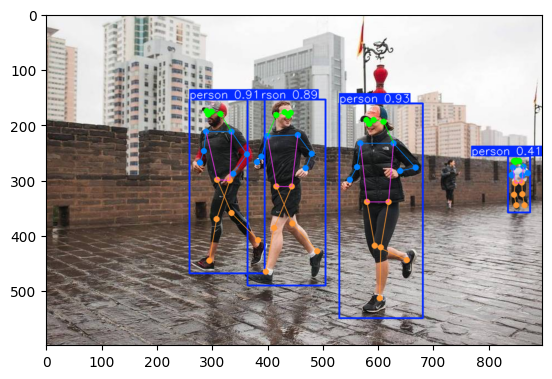

In [17]:
# Define image URL
#image = 'https://ultralytics.com/images/bus.jpg'  # Example image
image = cv2.imread('/home/mateo/Documentos/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/zuck_running.jpg')  # Read image using OpenCV

# Run inference
results = model(image)  # Model processes the image and predicts keypoints

# Extract first result
result = results[0]  # YOLO returns a list, we take the first item

# Plot results
annotated_image = result.plot()  # Draws keypoints and skeleton on the image

# Convert BGR (OpenCV) to RGB for display
annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(annotated_image)  # Display image
#plt.axis('off')  # Hide axis

### **Step 5:** Understanding the Output

Each detected person has:
- Bounding box
- Keypoints (joints like elbows, knees, etc.)

You can access raw keypoints like this:

0  Nose  
1  Left eye  
2  Right eye  
3  Left ear  
4  Right ear  
5  Left shoulder  
6  Right shoulder  
7  Left elbow  
8  Right elbow  
9  Left wrist  
10 Right wrist  
11 Left hip  
12 Right hip  
13 Left knee  
14 Right knee  
15 Left ankle  
16 Right ankle  

![body_coco](body_coco.png)

In [10]:
# Access keypoints data
keypoints = result.keypoints  # Contains all detected keypoints

# Print keypoints shape
print(keypoints.xy.shape)  # Shows the shape of the keypoints array (num_people, num_keypoints (COCO format), 2 (each point has x and y))

# ---Print keypoints---
# conf: confidence values for each keypoint, one vector per person, 17 keypoints in COCO format
# data: raw coordinates and confidence values, one vector per person, 17 keypoints in COCO format, with x, y, and confidence for each keypoint
# xy: combined array of coordinates, one vector per person, 17 keypoints in COCO format
# xyn: normalized coordinates, one vector per person, 17 keypoints in COCO format, normalized to [0, 1]
print(keypoints)  # Displays coordinates and confidence values

torch.Size([4, 17, 2])
ultralytics.engine.results.Keypoints object with attributes:

conf: tensor([[0.9968, 0.9992, 0.9720, 0.9879, 0.1064, 0.9984, 0.9985, 0.9966, 0.9827, 0.9973, 0.9834, 0.9994, 0.9990, 0.9988, 0.9946, 0.9960, 0.9943],
        [0.9877, 0.9947, 0.8206, 0.9789, 0.0840, 0.9984, 0.9954, 0.9963, 0.9683, 0.9963, 0.9840, 0.9990, 0.9986, 0.9986, 0.9982, 0.9944, 0.9962],
        [0.9960, 0.9674, 0.9985, 0.1879, 0.9851, 0.9983, 0.9972, 0.9953, 0.9659, 0.9943, 0.9635, 0.9992, 0.9987, 0.9988, 0.9966, 0.9959, 0.9916],
        [0.9186, 0.9368, 0.7490, 0.8923, 0.2187, 0.9962, 0.9938, 0.9812, 0.9129, 0.9656, 0.8662, 0.9956, 0.9930, 0.9864, 0.9770, 0.9546, 0.9342]])
data: tensor([[[5.8460e+02, 1.9808e+02, 9.9678e-01],
         [5.9298e+02, 1.9154e+02, 9.9918e-01],
         [5.7967e+02, 1.9146e+02, 9.7203e-01],
         [6.1005e+02, 1.9491e+02, 9.8787e-01],
         [5.7535e+02, 1.9531e+02, 1.0643e-01],
         [6.2870e+02, 2.3361e+02, 9.9842e-01],
         [5.6831e+02, 2.3343e+02, 9.

In [11]:
# Example: Accessing specific keypoint coordinates
keypoints.xy[0][5]  # (x, y) coordinates of left shoulder, first person, 6th keypoint (index 5)

tensor([628.6976, 233.6083])

In [12]:
# Example: Accessing specific keypoint data
keypoints.conf[0][5]  # confidence of left shoulder, first person, 6th keypoint (index 5)

tensor(0.9984)

### **Step 6:** Run Pose Estimation on Video

We can also process video streams frame-by-frame.

In [ ]:
# Run inference on a video file and save results
video_path = '/home/mateo/Documentos/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/jesper_annotated/jesper.mp4'  # Path to input video
output_path = '/home/mateo/Documentos/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/jesper_annotated.mp4'  # Path to save annotated video
model(
    source=video_path,
    save=True,
    project='/home/mateo/Documentos/Computer_Vision/UC.05 Image Segmentation & Pose Estimation',
    name='jesper_annotated'
)  # Runs inference on video and saves annotated output 


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/4163) /home/mateo/Documentos/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/jesper_annotated/jesper.mp4: 384x640 (no detections), 227.9ms
video 1/1 (frame 2/4163) /home/mateo/Documentos/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/jesper_annotated/jesper.mp4: 384x640 (no detections), 151.9ms
video 1/1 (frame 3/4163) /home/mateo/Documentos/Computer_Vision/UC.05 Image Segmentation & Pose Estimation/jesper_annota

You have learned:
- How to use YOLO for pose estimation
- How to run inference on images and videos
- How to visualize and interpret keypoints

### **Individual Activity:**
- Propose an activity recognition task (e.g., wrist above head -> raising hand, knees bent -> sitting/squatting, etc.).
- Test the activity recognition task with your webcam.
- Present your work in class (5 pts.)
    - Clearly explain the selected activity and why it is relevant or useful (1 pt)
    - Identify and describe the specific code you implemented or modified -line by line- (2 pts)
    - Deliver a live webcam demonstration (pre-recorded videos will not be evaluated) (2 pts)

In [ ]:
from IPython.display import display, clear_output, Image

# 1. Usamos el modelo ya cargado en celdas anteriores: model
# 2. Inicializamos la captura de video usando la cámara principal (índice 0)
cap = cv2.VideoCapture(0)

frame_count = 0

# 3. Bucle para procesar el video frame por frame
while cap.isOpened():
    success, frame = cap.read()  # Leemos el frame actual de la cámara
    if not success:
        break  # Si no se puede leer el frame, salimos del bucle

    # 4. Ejecutamos la inferencia del modelo YOLO sobre el frame actual
    results = model(frame, verbose=False)

    # 5. Inicializamos variables de estado y color para el texto en pantalla
    estado = "De pie"
    color = (0, 255, 0)  # Verde por defecto

    # 6. Verificamos si el modelo detectó keypoints en el frame
    if results[0].keypoints is not None and len(results[0].keypoints.xy) > 0:

        # 7. Extraemos los puntos de la primera persona detectada
        keypoints = results[0].keypoints.xy[0]

        # 8. Nos aseguramos de que el modelo haya detectado al menos hasta las rodillas (punto 13/14)
        if len(keypoints) >= 15:

            # 9. Extraemos la coordenada Y de la Cadera izquierda (11) y Rodilla izquierda (13)
            # Usamos el índice 1 porque las coordenadas son [x, y]
            cadera_y = int(keypoints[11][1])
            rodilla_y = int(keypoints[13][1])

            # 10. Verificamos que ambos puntos estén visibles en la cámara (valor Y mayor a 0)
            if cadera_y > 0 and rodilla_y > 0:

                # 11. Calculamos la distancia vertical absoluta entre la cadera y la rodilla
                distancia_y = abs(cadera_y - rodilla_y)

                # 12. Lógica de detección
                if distancia_y < 60:
                    estado = "Sentadilla!"
                    color = (0, 0, 255)  # Rojo

    # 13. Dibujamos el esqueleto y las cajas generadas por YOLO sobre el frame original
    annotated_frame = results[0].plot()

    # 14. Superponemos el texto con el estado actual (De pie o Sentadilla)
    cv2.putText(annotated_frame, estado, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 4)

    # 15. Mostramos el resultado inline en el notebook (sin usar ventanas GUI de OpenCV)
    frame_count += 1
    if frame_count % 2 == 0:  # refresco cada 2 frames para mejor rendimiento
        ok, buffer = cv2.imencode(".jpg", annotated_frame)
        if ok:
            clear_output(wait=True)
            display(Image(data=buffer.tobytes()))

# 16. Liberamos la cámara (sin destroyAllWindows para evitar error en entorno sin GUI)
cap.release()
print("Captura finalizada.")

[ WARN:0@391.312] global cap_v4l.cpp:999 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@391.312] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>